In [1]:
#import libraries and dataset.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
Ford = pd.read_excel('C:/Users/mwang/Downloads/Ford.xlsx', sheet_name="ford")

In [2]:
#set dataset as dataframe, overview each variable and their mode.
Ford = pd.DataFrame(Ford)
Ford.info()
Ford.mode()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   transmission  17966 non-null  object 
 3   fuelType      17966 non-null  object 
 4   engineSize    17966 non-null  float64
 5   price         17966 non-null  int64  
 6   mileage       17966 non-null  int64  
 7   tax           17966 non-null  int64  
 8   mpg           17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


,model,year,transmission,fuelType,engineSize,price,mileage,tax,mpg
0,Fiesta,2017,Manual,Petrol,1.0,10000,10,145,65.7


In [3]:
#view descriptive statistics of the dataset
Ford.describe()

,year,engineSize,price,mileage,tax,mpg
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,1.350807,12279.534844,23362.608761,113.329456,57.906980
std,2.050336,0.432367,4741.343657,19472.054349,62.012456,10.125696
min,1996.000000,0.000000,495.000000,1.000000,0.000000,20.800000
25%,2016.000000,1.000000,8999.000000,9987.000000,30.000000,52.300000
50%,2017.000000,1.200000,11291.000000,18242.500000,145.000000,58.900000
75%,2018.000000,1.500000,15299.000000,31060.000000,145.000000,65.700000
max,2060.000000,5.000000,54995.000000,177644.000000,580.000000,201.800000


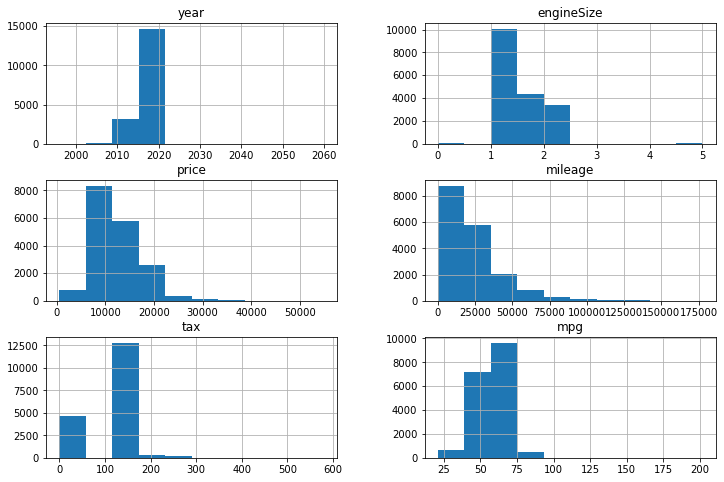

In [4]:
#1.numeric variable study
#1.1 histogram
plt.rcParams["figure.figsize"] = (12, 8)
all_hist = Ford.hist()

In [5]:
#1.2 calculate outliers
numeric = Ford[['year', 'engineSize','price','mileage','tax','mpg']]
Q1 = numeric.quantile(0.25)
Q3 = numeric.quantile(0.75)
IQR = Q3 - Q1
outlier_1= Q1 - 1.5 * IQR
outlier_2= Q3 + 1.5 * IQR
print(outlier_1)
print(outlier_2)

year           2013.00
engineSize        0.25
price          -451.00
mileage      -21622.50
tax            -142.50
mpg              32.20
dtype: float64
year           2021.00
engineSize        2.25
price         24749.00
mileage       62669.50
tax             317.50
mpg              85.80
dtype: float64


In [6]:
#1.3 drop all outliers for numeric variables, save as a new dataset and overview the info and mode.
Ford = Ford[((Ford['year'] >=2013) & (Ford['year'] <= 2021)) &
            ((Ford['engineSize'] >=0.25) & (Ford['engineSize'] <=2.25)) &
            (Ford['price'] <=24749) &
            (Ford['mileage'] <=62669.5) &
            (Ford['tax'] <=317.5) &
            ((Ford['mpg'] >=32.2) & (Ford['mpg'] <=85.8))]
Ford.info()
Ford.mode()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16448 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         16448 non-null  object 
 1   year          16448 non-null  int64  
 2   transmission  16448 non-null  object 
 3   fuelType      16448 non-null  object 
 4   engineSize    16448 non-null  float64
 5   price         16448 non-null  int64  
 6   mileage       16448 non-null  int64  
 7   tax           16448 non-null  int64  
 8   mpg           16448 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.3+ MB


,model,year,transmission,fuelType,engineSize,price,mileage,tax,mpg
0,Fiesta,2017,Manual,Petrol,1.0,10000,25000,145,65.7


In [7]:
#1.4 descriptive stats of data after dropping outliers
Ford.describe()

,year,engineSize,price,mileage,tax,mpg
count,16448.000000,16448.000000,16448.000000,16448.000000,16448.000000,16448.000000
mean,2017.114847,1.316652,12363.672240,20336.055265,113.119042,58.242729
std,1.530264,0.375388,3957.188108,13756.226101,59.107733,8.978561
min,2013.000000,1.000000,3295.000000,1.000000,0.000000,32.500000
25%,2016.000000,1.000000,9450.000000,9825.500000,125.000000,53.300000
50%,2017.000000,1.100000,11498.000000,17375.500000,145.000000,58.900000
75%,2018.000000,1.500000,15299.250000,28860.000000,145.000000,65.700000
max,2020.000000,2.200000,24690.000000,62664.000000,300.000000,85.600000


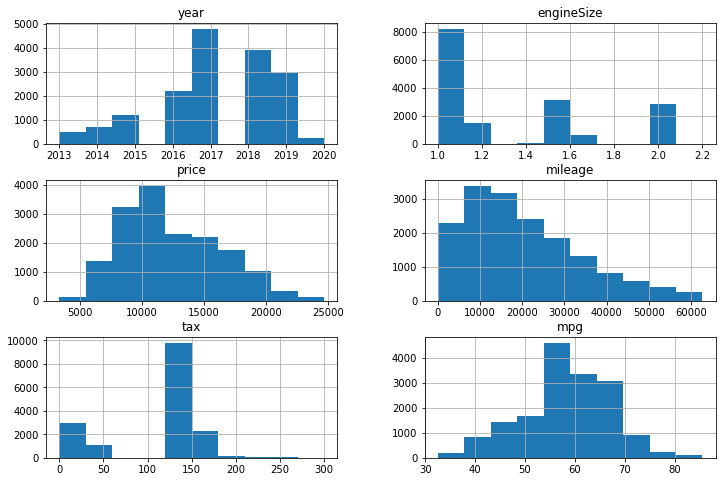

In [8]:
#1.5 histogram of new dataset
plt.rcParams["figure.figsize"] = (12, 8)
all_hist = Ford.hist()

engineSize    0.081287
mileage       0.457578
tax           0.273034
mpg           0.023765
dtype: float64


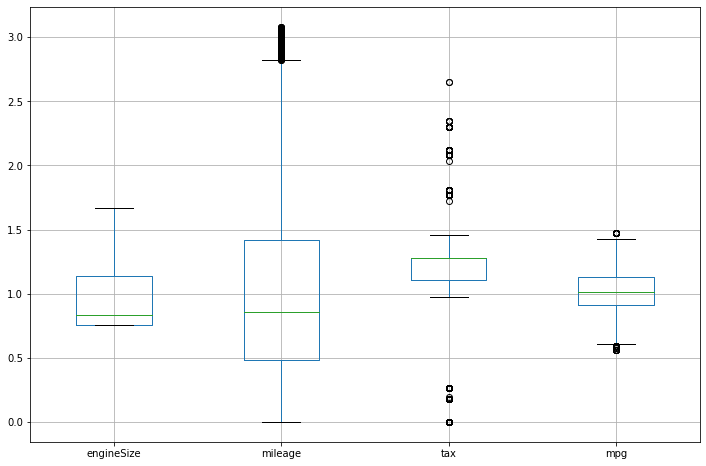

In [9]:
#2. Variable Selection
#2.1 normalize numeric independent variables other than year
Ford_n = Ford[['engineSize','mileage','tax','mpg']]
nml_Ford_n = Ford_n / Ford_n.mean()
nml_Ford_n.boxplot()
print(nml_Ford_n.var())

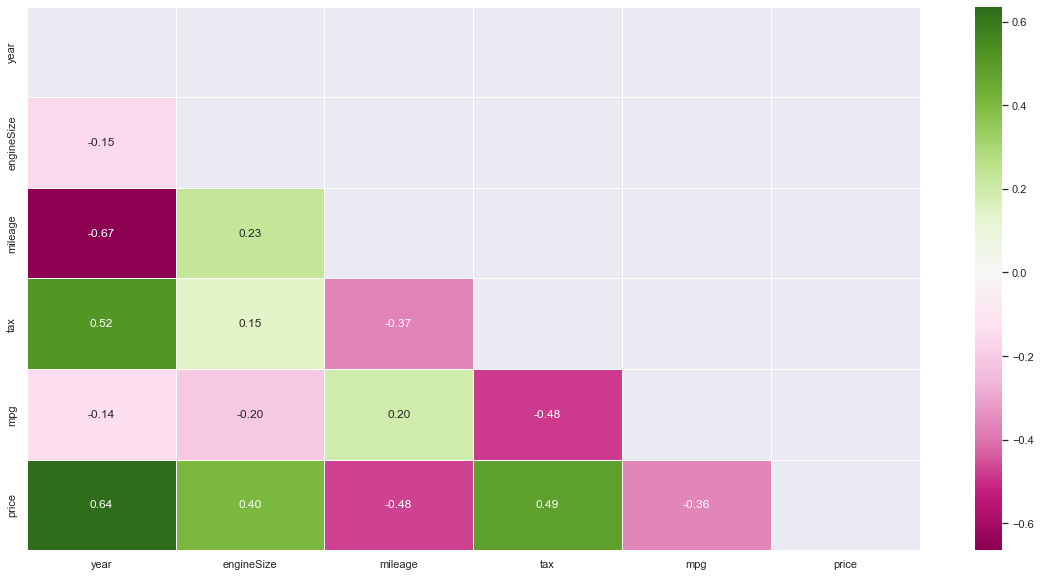

In [10]:
#2.2 correlation matrix
sns.set(rc = {'figure.figsize':(20,10)})
mask_1 = np.triu(np.ones_like(Ford[['year','engineSize','mileage','tax','mpg','price']].corr(), dtype=bool))
corr = sns.heatmap(Ford[['year','engineSize','mileage','tax','mpg','price']].corr(), mask = mask_1, center=0, linewidths=1, annot=True, cmap="PiYG", fmt=".2f")

In [11]:
#2.3.get dummies for string fields 
#2.3.1 remove whitespaces for string fields
Ford['model']=Ford['model'].str.strip()
Ford['transmission']=Ford['transmission'].str.strip()
Ford['fuelType']=Ford['fuelType'].str.strip()

In [12]:
#2.3.2 regroup "model"
Model = []
for i in Ford['model']:
        if i == 'Fiesta' :    Model.append('Fiesta')
        elif i == 'Focus':   Model.append('Focus')
        elif i =='Kuga':  Model.append('Kuga')
        elif i == 'EcoSport':  Model.append('EcoSport')  
        else: Model.append('Others')
Ford['Model'] = Model

In [13]:
#2.3.3 regroup "transmission"
Transmission = []
for i in Ford['transmission']:
        if i == 'Manual' : Transmission.append('1')    
        else: Transmission.append('0')
Ford['Transmission'] = Transmission
Ford['Transmission'] = Ford['Transmission'].astype('int')

In [14]:
#2.3.4 regroup "fueltype"
FuelType = []
for i in Ford['fuelType']:
        if i == 'Petrol' : FuelType.append('Petrol')   
        elif i == 'Diesel' : FuelType.append('Diesel')
        else: FuelType.append('Others')
Ford['FuelType'] = FuelType     

In [15]:
#2.3.5 duplicate regrouped fuel type and model,rename these fields for creating dummy variables
Ford['FT'] = Ford['FuelType']
Ford['MD'] = Ford['Model']

In [16]:
#2.3.6 get dummies for model and fuel type
Ford = pd.get_dummies(Ford,columns = ['MD'])
Ford = pd.get_dummies(Ford,columns = ['FT'])

In [17]:
#import libraries for regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics 
from sklearn.model_selection  import train_test_split
%matplotlib inline

In [18]:
#3. Modeling
#3.1 split train and test data
feature_cols = ['year','tax', 'engineSize','Transmission','MD_EcoSport', 'MD_Focus','MD_Fiesta','MD_Kuga','MD_Others','FT_Diesel','FT_Others','FT_Petrol']
X = Ford[feature_cols]
y = Ford.price
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)
X_train_lr = X_train.drop(['MD_Fiesta','FT_Petrol'], axis=1)
X_test_lr = X_test.drop(['MD_Fiesta','FT_Petrol'], axis=1)

In [19]:
#3.2 build, fit linear regression and print coefficients
lr = LinearRegression(fit_intercept = False)
lr_fit = lr.fit(X_train_lr, y_train)
coef_table = pd.DataFrame(list(X_train_lr.columns)).copy()
coef_table.insert(len(coef_table.columns),"coefs",lr.coef_.transpose())
print(coef_table)

              0        coefs
0          year     3.452716
1           tax    28.549099
2    engineSize  1323.695207
3  Transmission  -978.216491
4   MD_EcoSport   941.154917
5      MD_Focus  2111.422418
6       MD_Kuga  2303.668295
7     MD_Others   486.848919
8     FT_Diesel   975.090893
9     FT_Others  5525.194804


In [20]:
#3.2.1 overview r-squared of linear model
lr.score(X_train_lr, y_train)

0.41475479934085235

In [21]:
#3.2.2 print RMSE for train and test dataset
lr_pred_tr = lr.predict(X_train_lr)
lr_pred_ts = lr.predict(X_test_lr)
print ("RMSE in Linear Regression for training data is ", np.sqrt(metrics.mean_squared_error(y_train, lr_pred_tr)))
print ("RMSE in Linear Regression for test data is ", np.sqrt(metrics.mean_squared_error(y_test, lr_pred_ts)))

RMSE in Linear Regression for training data is  3007.788829029413
RMSE in Linear Regression for test data is  3066.7049421515517


In [22]:
#3.2.3 predict price for a manuel petrol Fiesta car produced in 2020 with a tax of $113 and 1.3 engine size
print(lr.predict([[2020,113,1.3,1,0,0,0,0,0,0]]))

[10943.12255973]


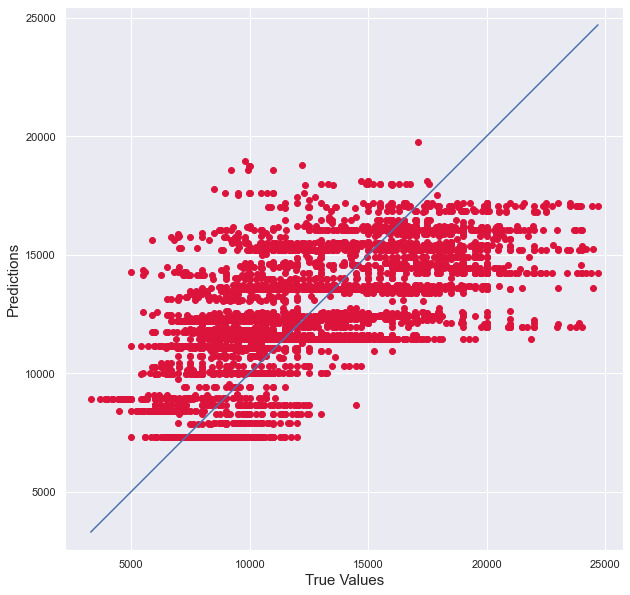

In [23]:
#3.2.4 visualize actual and predicted price in linear regression using test dataset
plt.figure(figsize=(10,10))
plt.scatter(y_test, lr_pred_ts, c='crimson')
p1 = max(max(lr_pred_ts), max(y_test))
p2 = min(min(lr_pred_ts), min(y_test))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.show()

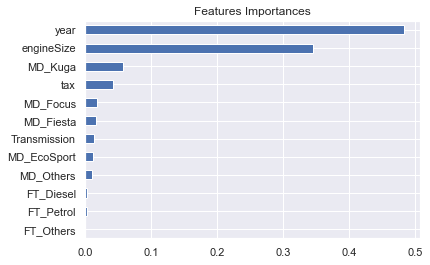

In [24]:
#3.3 build, fit random forest regression and print importance of features
rfr = RandomForestRegressor(n_estimators=100,max_depth=10)
rf = rfr.fit(X_train, y_train)
importance = pd.Series(data=rf.feature_importances_, index=X_train.columns).sort_values()
importance.plot(kind="barh")
plt.title("Features Importances")
plt.show()

In [25]:
#3.3.1 calculate fitting score of random forest regression
rfr.score(X_train, y_train)

0.8899665764847224

In [26]:
#3.3.2 print RMSE for train and test dataset
rfr_pred_tr = rfr.predict(X_train)
rfr_pred_ts = rfr.predict(X_test)
print ("RMSE in Random Forest Regression for training data is ", np.sqrt(metrics.mean_squared_error(y_train, rfr_pred_tr)))
print ("RMSE in Random Forest Regression for test data is ", np.sqrt(metrics.mean_squared_error(y_test, rfr_pred_ts)))

RMSE in Random Forest Regression for training data is  1304.1895749188877
RMSE in Random Forest Regression for test data is  1389.134051130634


In [36]:
#3.3.3 predict price for a manuel petrol Fiesta car produced in 2020 with a tax of $113 and 1.3 engine size
print(rfr.predict([[2020,113,1.3,1,0,0,1,0,0,0,0,1]]))

[12054.68672617]


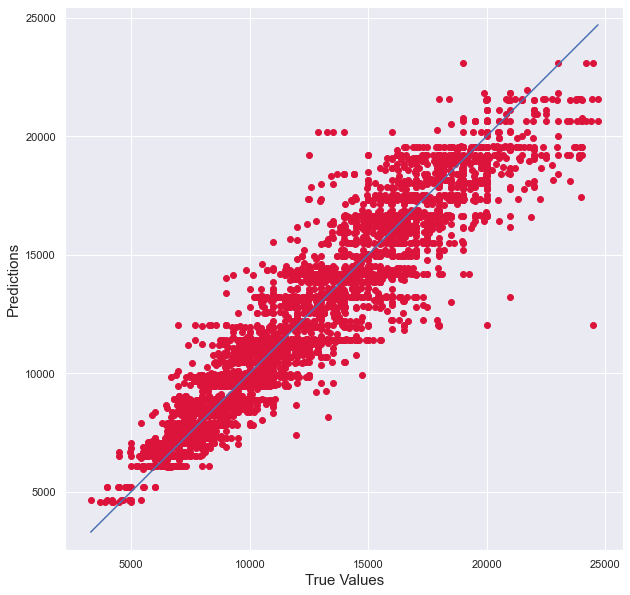

In [28]:
#3.3.4 visualize actual and predicted price in random forest regression using test dataset
plt.figure(figsize=(10,10))
plt.scatter(y_test,rfr_pred_ts, c='crimson')
p1 = max(max(rfr_pred_ts), max(y_test))
p2 = min(min(rfr_pred_ts), min(y_test))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('True Values', fontsize=15)
plt.ylabel('Predictions', fontsize=15)
plt.axis('equal')
plt.show()